In [2]:
import os, zipfile
import numpy as np
import tensorflow as tf
import cv2
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter

from google.colab import drive
drive.mount("/content/drive")

zip_path = "/content/drive/MyDrive/Parkinson's Dataset Final.zip"
extract_path = "/content/dataset"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

BASE = "/content/dataset/Parkinson's Dataset Final"
print("Extracted:", os.listdir(BASE))

Mounted at /content/drive
Extracted: ['New hand pd Dataset', 'Hand Pd']


In [3]:
!pip -q install imagehash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 12.0 MB/s eta 0:00:00


In [4]:
import imagehash
from PIL import Image
from collections import defaultdict

HANDPD_ROOT = os.path.join(BASE, "Hand Pd")
SPIRAL_ROOT = os.path.join(HANDPD_ROOT, "Spiral_HandPD")
MEANDER_ROOT = os.path.join(HANDPD_ROOT, "Meander_HandPD")

image_paths = []
labels = []

def collect_handpd(root):
    for cls in os.listdir(root):
        cls_path = os.path.join(root, cls)
        if not os.path.isdir(cls_path):
            continue

        cls_lower = cls.lower()
        if cls_lower == "healthy":
            lab = 0
        elif cls_lower == "parkinson":
            lab = 1
        else:
            continue

        for r, d, files in os.walk(cls_path):
            for f in files:
                if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
                    image_paths.append(os.path.join(r, f))
                    labels.append(lab)

collect_handpd(SPIRAL_ROOT)
collect_handpd(MEANDER_ROOT)

print("Raw HandPD Total:", len(image_paths))
print("Healthy:", labels.count(0))
print("Parkinson:", labels.count(1))

Raw HandPD Total: 808
Healthy: 216
Parkinson: 592


In [5]:
def get_phash(img_path):
    try:
        img = Image.open(img_path).convert("L").resize((224,224))
        return imagehash.phash(img)
    except:
        return None

PHASH_DISTANCE_THRESHOLD = 4

hash_to_paths = defaultdict(list)

for p in tqdm(image_paths, desc="Hashing"):
    h = get_phash(p)
    if h is not None:
        hash_to_paths[str(h)].append(p)

hash_list = list(hash_to_paths.keys())
used = set()
final_keep = []

for i in tqdm(range(len(hash_list)), desc="Removing duplicates"):
    if hash_list[i] in used:
        continue

    base_hash = imagehash.hex_to_hash(hash_list[i])
    used.add(hash_list[i])
    final_keep.append(hash_list[i])

    for j in range(i+1, len(hash_list)):
        if hash_list[j] in used:
            continue
        compare_hash = imagehash.hex_to_hash(hash_list[j])
        if base_hash - compare_hash <= PHASH_DISTANCE_THRESHOLD:
            used.add(hash_list[j])

path_to_label = dict(zip(image_paths, labels))

clean_paths = []
clean_labels = []

for h in final_keep:
    p = hash_to_paths[h][0]
    clean_paths.append(p)
    clean_labels.append(path_to_label[p])

print("\nCLEAN HANDPD")
print("Images:", len(clean_paths))
print("Healthy:", clean_labels.count(0))
print("Parkinson:", clean_labels.count(1))

Removing duplicates: 100%|██████████| 735/735 [00:06<00:00, 116.63it/s]


CLEAN HANDPD
Images: 558
Healthy: 123
Parkinson: 435


In [6]:
paths = np.array(clean_paths)
labels = np.array(clean_labels)

train_paths, test_paths, y_train, y_test = train_test_split(
    paths, labels,
    test_size=0.20,
    random_state=42,
    stratify=labels
)

val_paths, test_paths, y_val, y_test = train_test_split(
    test_paths, y_test,
    test_size=0.50,
    random_state=42,
    stratify=y_test
)

print("Train:", Counter(y_train))
print("Val  :", Counter(y_val))
print("Test :", Counter(y_test))

Train: Counter({np.int64(1): 348, np.int64(0): 98})
Val  : Counter({np.int64(1): 44, np.int64(0): 12})
Test : Counter({np.int64(1): 43, np.int64(0): 13})


In [7]:


IMG_SIZE = 224
BATCH_SIZE = 16

def preprocess(path):
    path = path.numpy().decode()

    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # CLAHE only (no denoise, no heavy filters)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)

    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=-1)

    return img


def tf_preprocess(path, label):
    img = tf.py_function(preprocess, [path], tf.float32)
    img.set_shape((IMG_SIZE, IMG_SIZE, 1))
    label = tf.cast(label, tf.float32)
    return img, label



from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomContrast(0.1),
], name="augmentation")



def make_train_ds(paths, labels):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.shuffle(2000)
    ds = ds.map(tf_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)


    ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


def make_eval_ds(paths, labels):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(tf_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_train_ds(train_paths, y_train)
val_ds   = make_eval_ds(val_paths, y_val)
test_ds  = make_eval_ds(test_paths, y_test)

print("tf.data pipeline ready ")

tf.data pipeline ready 


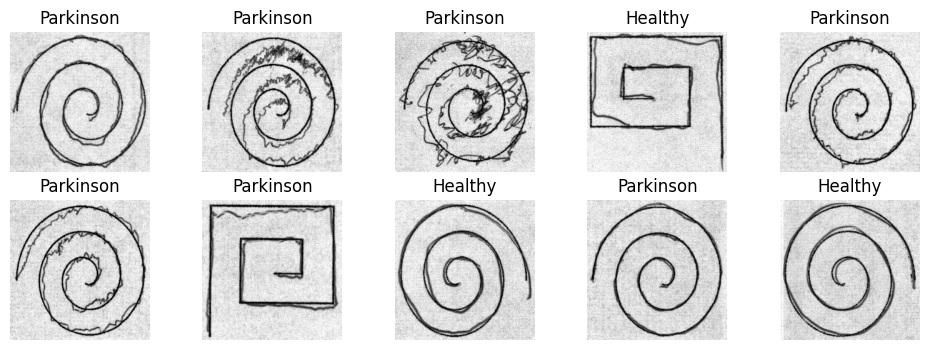

In [8]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    images = images.numpy()
    labels = labels.numpy()

    plt.figure(figsize=(12,4))
    for i in range(10):
        plt.subplot(2,5,i+1)
        plt.imshow(images[i].squeeze(), cmap="gray")
        plt.title("Healthy" if labels[i]==0 else "Parkinson")
        plt.axis("off")
    plt.show()

In [9]:
for imgs, _ in train_ds.take(1):
    print("Min:", imgs.numpy().min())
    print("Max:", imgs.numpy().max())

Min: 0.0
Max: 1.0162163


In [10]:
import random

TARGET_PER_CLASS = 1000


healthy_paths = train_paths[y_train == 0]
parkinson_paths = train_paths[y_train == 1]

print("\nOriginal Train Distribution")
print("Healthy:", len(healthy_paths))
print("Parkinson:", len(parkinson_paths))


def oversample_class(paths, target_size):
    paths = list(paths)
    current_size = len(paths)

    if current_size >= target_size:
        return paths[:target_size]

    extra_needed = target_size - current_size
    extra_samples = random.choices(paths, k=extra_needed)

    return paths + extra_samples



healthy_balanced = oversample_class(healthy_paths, TARGET_PER_CLASS)
parkinson_balanced = oversample_class(parkinson_paths, TARGET_PER_CLASS)


train_paths_balanced = np.array(healthy_balanced + parkinson_balanced)
y_train_balanced = np.array([0]*TARGET_PER_CLASS + [1]*TARGET_PER_CLASS)


indices = np.arange(len(train_paths_balanced))
np.random.shuffle(indices)

train_paths_balanced = train_paths_balanced[indices]
y_train_balanced = y_train_balanced[indices]

print("\nAfter Oversampling")
print("Train Balanced:", Counter(y_train_balanced))
print("Total Train Size:", len(train_paths_balanced))


Original Train Distribution
Healthy: 98
Parkinson: 348

After Oversampling
Train Balanced: Counter({np.int64(1): 1000, np.int64(0): 1000})
Total Train Size: 2000


In [11]:
print("\nLeakage Check")
print("Train-Val overlap :", len(set(train_paths_balanced) & set(val_paths)))
print("Train-Test overlap:", len(set(train_paths_balanced) & set(test_paths)))
print("Val-Test overlap  :", len(set(val_paths) & set(test_paths)))


Leakage Check
Train-Val overlap : 0
Train-Test overlap: 0
Val-Test overlap  : 0


In [12]:
train_ds = make_train_ds(train_paths_balanced, y_train_balanced)
val_ds   = make_eval_ds(val_paths, y_val)
test_ds  = make_eval_ds(test_paths, y_test)

print("Final dataset ready ")

Final dataset ready 


In [13]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow import keras

In [14]:
IMG_SIZE = 224
PATCH_SIZE = 16

class PatchEmbedding(layers.Layer):
    def __init__(self, patch_size, embed_dim):
        super().__init__()
        self.embed_dim = embed_dim
        self.proj = layers.Conv2D(
            filters=embed_dim,
            kernel_size=patch_size,
            strides=patch_size,
            padding="valid"
        )

    def call(self, x):
        x = self.proj(x)
        x = tf.reshape(x, [tf.shape(x)[0], -1, self.embed_dim])
        return x

In [15]:
class AddPositionEmbedding(layers.Layer):
    def __init__(self, num_patches, embed_dim):
        super().__init__()
        self.num_patches = num_patches
        self.embed_dim = embed_dim

    def build(self, input_shape):
        self.pos_embed = self.add_weight(
            shape=(1, self.num_patches + 1, self.embed_dim),
            initializer="random_normal",
            trainable=True
        )
        self.cls_token = self.add_weight(
            shape=(1, 1, self.embed_dim),
            initializer="random_normal",
            trainable=True
        )

    def call(self, x):
        batch = tf.shape(x)[0]
        cls = tf.repeat(self.cls_token, repeats=batch, axis=0)
        x = tf.concat([cls, x], axis=1)
        return x + self.pos_embed

In [16]:
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim):
        super().__init__()
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn = layers.MultiHeadAttention(
            num_heads=2,   # small because dim decreases
            key_dim=max(embed_dim // 2, 1)
        )
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp = keras.Sequential([
            layers.Dense(embed_dim * 2, activation="gelu"),
            layers.Dense(embed_dim)
        ])

    def call(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

In [17]:
class Projection(layers.Layer):
    def __init__(self, new_dim):
        super().__init__()
        self.new_dim = new_dim

    def call(self, x):
        return layers.Dense(self.new_dim)(x)

In [18]:
def build_hierarchical_vit():

    dims = [526, 512, 256, 64, 32, 16, 8, 4, 2]
    NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

    x = PatchEmbedding(PATCH_SIZE, dims[0])(inputs)
    x = AddPositionEmbedding(NUM_PATCHES, dims[0])(x)

    for i in range(len(dims) - 1):
        x = TransformerBlock(dims[i])(x)
        x = Projection(dims[i + 1])(x)

    x = layers.LayerNormalization(epsilon=1e-6)(x)

    cls = x[:, 0]

    outputs = layers.Dense(2, activation="softmax")(cls)

    model = keras.Model(inputs, outputs)
    return model


vit_model = build_hierarchical_vit()
vit_model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_embedding                 │ (None, None, 526)      │       135,182 │
│ (PatchEmbedding)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_position_embedding          │ (None, 197, 526)       │       104,148 │
│ (AddPositionEmbedding)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 197, 526)       │     2,219,194 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection (Projection)         │ (None, 197, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 197, 512)       │     2,102,784 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_1 (Projection)       │ (None, 197, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 197, 256)       │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_2 (Projection)       │ (None, 197, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 197, 64)        │        33,472 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_3 (Projection)       │ (None, 197, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_4             │ (None, 197, 32)        │         8,544 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_4 (Projection)       │ (None, 197, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_5             │ (None, 197, 16)        │         2,224 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_5 (Projection)       │ (None, 197, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_6             │ (None, 197, 8)         │           600 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_6 (Projection)       │ (None, 197, 4)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_7             │ (None, 197, 4)         │           172 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_7 (Projection)       │ (None, 197, 2)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_16          │ (None, 197, 2)         │             

 Total params: 5,133,434 (19.58 MB)

 Trainable params: 5,133,434 (19.58 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
vit_model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=5e-5,
        weight_decay=1e-4
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [20]:
history = vit_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60
)

Epoch 1/60


ValueError: Exception encountered when calling Projection.call().

[1mtf.function only supports singleton tf.Variables created on the first call. Make sure the tf.Variable is only created once or created outside tf.function. See https://www.tensorflow.org/guide/function#creating_tfvariables for more information.[0m

Arguments received by Projection.call():
  • x=tf.Tensor(shape=(None, 197, 526), dtype=float32)

In [21]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow import keras

IMG_SIZE = 224
PATCH_SIZE = 16

# Exact decreasing order you requested
DIMS = [526, 512, 256, 128, 64, 32, 16, 8, 4, 2]


# -------- Patch Embedding --------
class PatchEmbedding(layers.Layer):
    def __init__(self, patch_size, embed_dim):
        super().__init__()
        self.embed_dim = embed_dim
        self.proj = layers.Conv2D(
            filters=embed_dim,
            kernel_size=patch_size,
            strides=patch_size,
            padding="valid"
        )

    def call(self, x):
        x = self.proj(x)
        x = tf.reshape(x, [tf.shape(x)[0], -1, self.embed_dim])
        return x


# -------- CLS + Position --------
class AddPositionEmbedding(layers.Layer):
    def __init__(self, num_patches, embed_dim):
        super().__init__()
        self.num_patches = num_patches
        self.embed_dim = embed_dim

    def build(self, input_shape):
        self.pos_embed = self.add_weight(
            shape=(1, self.num_patches + 1, self.embed_dim),
            initializer="random_normal",
            trainable=True
        )
        self.cls_token = self.add_weight(
            shape=(1, 1, self.embed_dim),
            initializer="random_normal",
            trainable=True
        )

    def call(self, x):
        batch = tf.shape(x)[0]
        cls = tf.repeat(self.cls_token, repeats=batch, axis=0)
        x = tf.concat([cls, x], axis=1)
        return x + self.pos_embed


# -------- Transformer Block --------
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim):
        super().__init__()
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn = layers.MultiHeadAttention(
            num_heads=2,
            key_dim=max(embed_dim // 2, 1)
        )
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp = keras.Sequential([
            layers.Dense(embed_dim * 2, activation="gelu"),
            layers.Dense(embed_dim)
        ])

    def call(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


# -------- Projection Layer --------
class Projection(layers.Layer):
    def __init__(self, new_dim):
        super().__init__()
        self.proj = layers.Dense(new_dim)

    def call(self, x):
        return self.proj(x)


# -------- Build Model --------
def build_hierarchical_vit():

    NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

    # Initial embedding
    x = PatchEmbedding(PATCH_SIZE, DIMS[0])(inputs)
    x = AddPositionEmbedding(NUM_PATCHES, DIMS[0])(x)

    # Transformer + Projection chain
    for i in range(len(DIMS) - 1):
        x = TransformerBlock(DIMS[i])(x)
        x = Projection(DIMS[i + 1])(x)

    x = layers.LayerNormalization(epsilon=1e-6)(x)

    # Take CLS token from LAST transformer
    cls = x[:, 0]

    outputs = layers.Dense(2, activation="softmax")(cls)

    model = keras.Model(inputs, outputs)
    return model


vit_model = build_hierarchical_vit()
vit_model.summary()

Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_embedding_1               │ (None, None, 526)      │       135,182 │
│ (PatchEmbedding)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_position_embedding_1        │ (None, 197, 526)       │       104,148 │
│ (AddPositionEmbedding)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_8             │ (None, 197, 526)       │     2,219,194 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_8 (Projection)       │ (None, 197, 512)       │       269,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_9             │ (None, 197, 512)       │     2,102,784 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_9 (Projection)       │ (None, 197, 256)       │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_10            │ (None, 197, 256)       │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_10 (Projection)      │ (None, 197, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_11            │ (None, 197, 128)       │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_11 (Projection)      │ (None, 197, 64)        │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_12            │ (None, 197, 64)        │        33,472 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_12 (Projection)      │ (None, 197, 32)        │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_13            │ (None, 197, 32)        │         8,544 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_13 (Projection)      │ (None, 197, 16)        │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_14            │ (None, 197, 16)        │         2,224 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_14 (Projection)      │ (None, 197, 8)         │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_15            │ (None, 197, 8)         │           600 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_15 (Projection)      │ (None, 197, 4)         │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_16            │ (None, 197, 4)         │           17

 Total params: 5,711,008 (21.79 MB)

 Trainable params: 5,711,008 (21.79 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
vit_model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=2e-5,
        weight_decay=1e-4
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [23]:
history = vit_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60
)

Epoch 1/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 93s 254ms/step - accuracy: 0.5069 - loss: 0.6932 - val_accuracy: 0.7857 - val_loss: 0.6760
Epoch 2/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 37s 165ms/step - accuracy: 0.5022 - loss: 0.6935 - val_accuracy: 0.7857 - val_loss: 0.6766
Epoch 3/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 152ms/step - accuracy: 0.5080 - loss: 0.6931 - val_accuracy: 0.7857 - val_loss: 0.6773
Epoch 4/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 161ms/step - accuracy: 0.5004 - loss: 0.6935 - val_accuracy: 0.7857 - val_loss: 0.6781
Epoch 5/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 157ms/step - accuracy: 0.5025 - loss: 0.6934 - val_accuracy: 0.7857 - val_loss: 0.6786
Epoch 6/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 166ms/step - accuracy: 0.4955 - loss: 0.6937 - val_accuracy: 0.7857 - val_loss: 0.6794
Epoch 7/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 151ms/step - accuracy: 0.5032 - loss: 0.6933 - val_accuracy: 0.7857 - val_loss: 0.6799
Epoch 8/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 161ms/step - accuracy: 0.5068 - loss: 0

KeyboardInterrupt: 

In [24]:
import numpy as np

preds = vit_model.predict(val_ds)
pred_classes = np.argmax(preds, axis=1)

print("Predicted class counts:", np.bincount(pred_classes))

4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step
Predicted class counts: [ 0 56]


In [25]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow import keras

IMG_SIZE = 224
PATCH_SIZE = 16

# Transformer dimensions (stop at 16)
DIMS = [526, 512, 256, 128, 64, 32, 16]


# -------- Patch Embedding --------
class PatchEmbedding(layers.Layer):
    def __init__(self, patch_size, embed_dim):
        super().__init__()
        self.embed_dim = embed_dim
        self.proj = layers.Conv2D(
            filters=embed_dim,
            kernel_size=patch_size,
            strides=patch_size,
            padding="valid"
        )

    def call(self, x):
        x = self.proj(x)
        x = tf.reshape(x, [tf.shape(x)[0], -1, self.embed_dim])
        return x


# -------- CLS + Position --------
class AddPositionEmbedding(layers.Layer):
    def __init__(self, num_patches, embed_dim):
        super().__init__()
        self.num_patches = num_patches
        self.embed_dim = embed_dim

    def build(self, input_shape):
        self.pos_embed = self.add_weight(
            shape=(1, self.num_patches + 1, self.embed_dim),
            initializer="random_normal",
            trainable=True
        )
        self.cls_token = self.add_weight(
            shape=(1, 1, self.embed_dim),
            initializer="random_normal",
            trainable=True
        )

    def call(self, x):
        batch = tf.shape(x)[0]
        cls = tf.repeat(self.cls_token, repeats=batch, axis=0)
        x = tf.concat([cls, x], axis=1)
        return x + self.pos_embed


# -------- Transformer Block --------
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim):
        super().__init__()
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn = layers.MultiHeadAttention(
            num_heads=2,
            key_dim=max(embed_dim // 2, 1)
        )
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp = keras.Sequential([
            layers.Dense(embed_dim * 2, activation="gelu"),
            layers.Dense(embed_dim)
        ])

    def call(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


# -------- Projection Layer --------
class Projection(layers.Layer):
    def __init__(self, new_dim):
        super().__init__()
        self.proj = layers.Dense(new_dim)

    def call(self, x):
        return self.proj(x)


# -------- Build Model --------
def build_model():

    NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

    x = PatchEmbedding(PATCH_SIZE, DIMS[0])(inputs)
    x = AddPositionEmbedding(NUM_PATCHES, DIMS[0])(x)

    # Transformer + Projection chain
    for i in range(len(DIMS) - 1):
        x = TransformerBlock(DIMS[i])(x)
        x = Projection(DIMS[i + 1])(x)

    x = layers.LayerNormalization(epsilon=1e-6)(x)

    cls = x[:, 0]  # 16-dim feature

    # Dense head below transformer
    x = layers.Dense(8, activation="relu")(cls)
    x = layers.Dense(4, activation="relu")(x)

    outputs = layers.Dense(2, activation="softmax")(x)

    model = keras.Model(inputs, outputs)
    return model


vit_model = build_model()
vit_model.summary()

Model: "functional_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_20 (InputLayer)     │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_embedding_2               │ (None, None, 526)      │       135,182 │
│ (PatchEmbedding)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_position_embedding_2        │ (None, 197, 526)       │       104,148 │
│ (AddPositionEmbedding)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_17            │ (None, 197, 526)       │     2,219,194 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_17 (Projection)      │ (None, 197, 512)       │       269,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_18            │ (None, 197, 512)       │     2,102,784 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_18 (Projection)      │ (None, 197, 256)       │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_19            │ (None, 197, 256)       │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_19 (Projection)      │ (None, 197, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_20            │ (None, 197, 128)       │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_20 (Projection)      │ (None, 197, 64)        │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_21            │ (None, 197, 64)        │        33,472 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_21 (Projection)      │ (None, 197, 32)        │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_22            │ (None, 197, 32)        │         8,544 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_22 (Projection)      │ (None, 197, 16)        │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_48          │ (None, 197, 16)        │            32 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item_2 (GetItem)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_80 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_82 (Dense)                │ (None, 2)              │            10 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 5,708,034 (21.77 MB)

 Trainable params: 5,708,034 (21.77 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# ===============================
# Compile
# ===============================

vit_model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-4,
        weight_decay=1e-4
    ),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [28]:
# ===============================
# Callbacks
# ===============================

callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        "best_hierarchical_vit.keras",
        monitor="val_auc",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    )
]

In [30]:
vit_model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-4,
        weight_decay=1e-4
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [31]:
# ===============================
# Train
# ===============================

history = vit_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.5077 - loss: 0.6947

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:302: UserWarning: Can save best model only with val_auc available.
  if self._should_save_model(epoch, batch, logs, filepath):


125/125 ━━━━━━━━━━━━━━━━━━━━ 64s 221ms/step - accuracy: 0.5076 - loss: 0.6946 - val_accuracy: 0.2143 - val_loss: 0.6932 - learning_rate: 1.0000e-04
Epoch 2/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 162ms/step - accuracy: 0.4889 - loss: 0.6932 - val_accuracy: 0.2143 - val_loss: 0.6932 - learning_rate: 1.0000e-04
Epoch 3/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 150ms/step - accuracy: 0.5143 - loss: 0.6932 - val_accuracy: 0.2143 - val_loss: 0.6932 - learning_rate: 1.0000e-04
Epoch 4/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 160ms/step - accuracy: 0.4869 - loss: 0.6932 - val_accuracy: 0.2143 - val_loss: 0.6932 - learning_rate: 1.0000e-04
Epoch 5/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.5089 - loss: 0.6932
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 151ms/step - accuracy: 0.5088 - loss: 0.6932 - val_accuracy: 0.2143 - val_loss: 0.6932 - learning_rate: 1.0000e-04
Epoch 6/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 161ms/step - accura